<a href="https://colab.research.google.com/github/SaiPranathi16/envision-ai-interior-redesign/blob/main/Envision_Week2_Furniture.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Envision — Week 2: Furniture Detection (YOLOv8)

**Before running:** `Runtime > Change runtime type` should still be set to **T4 GPU**.

This notebook:
1. Re-mounts your Drive and reloads your sample photo from Week 1
2. Loads a pretrained YOLOv8 model
3. Detects furniture in your room photo and draws bounding boxes
4. Saves a list of detected items — this feeds your shopping list and click-to-edit features later

In [11]:
from google.colab import files
import shutil

uploaded = files.upload()
new_filename = list(uploaded.keys())[0]
shutil.copy(new_filename, f'{PROJECT_DIR}/sample_images/{new_filename}')
print('Saved to Drive:', new_filename)

Saving Furnishedroom.jpg to Furnishedroom (1).jpg
Saved to Drive: Furnishedroom (1).jpg


In [1]:
from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR = '/content/drive/MyDrive/Envision_Project'
import os
print('Files in your sample_images folder:')
print(os.listdir(f'{PROJECT_DIR}/sample_images'))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Files in your sample_images folder:
['Room.jpg']


## Set your sample image filename
Copy the exact filename from the list printed above and paste it below.

In [7]:
sample_filename = 'Furnishedroom.jpg'
sample_path = f'{PROJECT_DIR}/sample_images/{sample_filename}'

import os
assert os.path.exists(sample_path), 'File not found — check the filename matches exactly, including the extension.'
print('Found:', sample_path)

Found: /content/drive/MyDrive/Envision_Project/sample_images/Furnishedroom.jpg


## Install and load YOLOv8

In [8]:
!pip install -q ultralytics

from ultralytics import YOLO

# yolov8n = nano version, fastest, good enough for this project
model = YOLO('yolov8n.pt')
print('YOLOv8 loaded.')

YOLOv8 loaded.


## Run detection on your room photo

Note: standard YOLOv8 is trained on the COCO dataset, which includes some furniture classes (chair, couch, bed, dining table, tv, potted plant) but not every furniture type (e.g. no dedicated "curtain" or "rug" class). This is normal — we're using it as a starting point. If you want more furniture-specific categories later, that would mean fine-tuning on a furniture dataset, which is an optional stretch goal, not required for your core project.


image 1/1 /content/drive/MyDrive/Envision_Project/sample_images/Furnishedroom.jpg: 448x640 2 couchs, 10.9ms
Speed: 3.3ms preprocess, 10.9ms inference, 57.8ms postprocess per image at shape (1, 3, 448, 640)


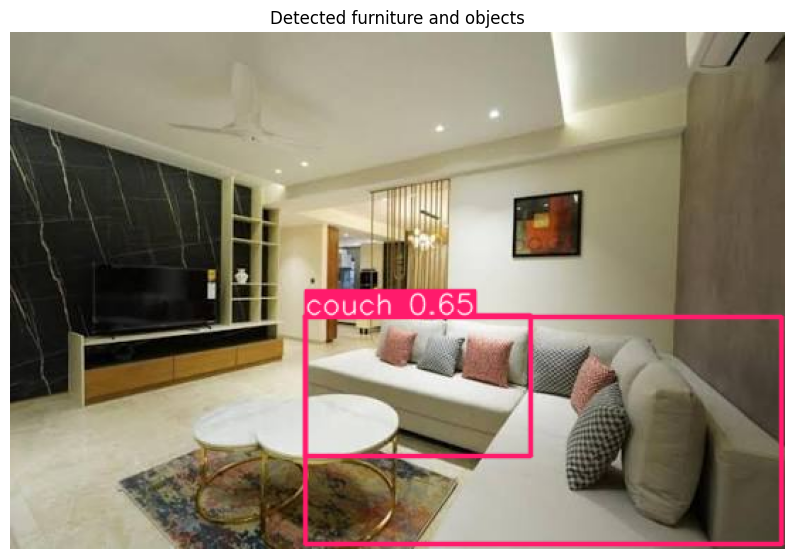

In [9]:
results = model(sample_path)

result = results[0]
annotated = result.plot()  # numpy array with boxes drawn

import matplotlib.pyplot as plt
import cv2

annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(10, 8))
plt.imshow(annotated_rgb)
plt.axis('off')
plt.title('Detected furniture and objects')
plt.show()

## Print and save the detected items list
This is the structured data your shopping-list feature will use later.

In [5]:
import json

detected_items = []
for box in result.boxes:
    class_id = int(box.cls[0])
    class_name = model.names[class_id]
    confidence = float(box.conf[0])
    xyxy = box.xyxy[0].tolist()
    detected_items.append({
        'item': class_name,
        'confidence': round(confidence, 3),
        'box': [round(v, 1) for v in xyxy]
    })

print(f'Detected {len(detected_items)} item(s):')
for item in detected_items:
    print(f"  - {item['item']} (confidence: {item['confidence']})")

with open(f'{PROJECT_DIR}/outputs/detected_furniture.json', 'w') as f:
    json.dump(detected_items, f, indent=2)

print('\nSaved to Drive: outputs/detected_furniture.json')

Detected 0 item(s):

Saved to Drive: outputs/detected_furniture.json


## What's next (Week 3)
- Load Stable Diffusion + ControlNet
- Feed in your Week 1 structure map (Canny or SegFormer) as the conditioning input
- Write and test your first style prompt — this is the core generation module, and where most of your iteration time will go

**If detection looked sparse or missed obvious furniture:** that's expected with the nano model on a cluttered or unusually angled photo. Try a clearer, well-lit photo, or note this as a known limitation in your report (COCO's furniture coverage is limited) — it's a legitimate, honest observation for your methodology section.